Лабораторна робота 2.
Вступ до машинного навчання.
Аналіз даних. Бібліотека Pandas.
Виконала:
Студентка ФІТ 4-9
Фесюк Олеся


https://github.com/Olllesssyya/Machinelearning/

In [ ]:
import numpy as np
import pandas as pd
import requests

**1. Завдання 1**
Обробка та аналіз даних про ВВП країни. Датасет було отримано з Вікіпедії з використанням бібліотеки Pandas

Вивести перші 5 рядків датасета

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)   # зчитати всі таблиці
df = tables[2]                # потрібна таблиця (може змінюватись!), номери не є сталими!
df.head()

/tmp/ipython-input-4245129341.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)   # зчитати всі таблиці


,Country/Territory,IMF (2025)[1][6],World Bank (2022–24)[7],United Nations (2023)[8]
0,World,117165394,111326370,100834796
1,United States,30615743,29184890,27720700
2,China[n 1],19398577,18743803,17794782
3,Germany,5013574,4659929,4525704
4,Japan,4279828,4026211,4204495


In [ ]:
df.columns

Index(['Country/Territory', 'IMF (2025)[1][6]', 'World Bank (2022–24)[7]',
       'United Nations (2023)[8]'],
      dtype='object')

2.Визначити розмір датасета.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2025)[1][6]          222 non-null    object
 2   World Bank (2022–24)[7]   222 non-null    object
 3   United Nations (2023)[8]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


3.Визначити оптимальну кількість стовпців.

In [ ]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)  # прибрати [1], [6], ...
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2025),World Bank (2022–24),United Nations (2023)
0,World,117165394,111326370,100834796
1,United States,30615743,29184890,27720700
2,China[n 1],19398577,18743803,17794782
3,Germany,5013574,4659929,4525704
4,Japan,4279828,4026211,4204495
...,...,...,...,...
217,Kiribati,312,308,289
218,Marshall Islands,297,280,270
219,Nauru,169,160,176
220,Montserrat,—,—,80


4. Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2025),0
World Bank (2022–24),0
United Nations (2023),0


In [ ]:
# Convert columns to float type
df['IMF (2025)'] = pd.to_numeric(df['IMF (2025)'], errors='coerce')
df['World Bank (2022–24)'] = pd.to_numeric(df['World Bank (2022–24)'], errors='coerce')
df['United Nations (2023)'] = pd.to_numeric(df['United Nations (2023)'], errors='coerce')

print(f'Types:\n{df.dtypes}')
df.head(10)

Types:
Country                   object
IMF (2025)               float64
World Bank (2022–24)     float64
United Nations (2023)    float64
dtype: object


,Country,IMF (2025),World Bank (2022–24),United Nations (2023)
0,World,117165394.0,111326370.0,100834796.0
1,United States,30615743.0,29184890.0,27720700.0
2,China[n 1],19398577.0,18743803.0,17794782.0
3,Germany,5013574.0,4659929.0,4525704.0
4,Japan,4279828.0,4026211.0,4204495.0
5,India,4125213.0,3912686.0,3575778.0
6,United Kingdom,3958780.0,3643834.0,3380855.0
7,France,3361557.0,3162079.0,3051832.0
8,Italy,2543677.0,2372775.0,2300941.0
9,Russia,2540656.0,2173836.0,2008419.0


In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2025),32
World Bank (2022–24),12
United Nations (2023),9


In [ ]:
# Replace NaN with mean of the row. Ignore first column (Country)
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)

df.isnull().sum()

,0
Country,0
IMF (2025),0
World Bank (2022–24),0
United Nations (2023),0


5. Ще раз перевірити наявність пропущених значень.

In [ ]:
df


,Country,IMF (2025),World Bank (2022–24),United Nations (2023)
0,World,117165394.0,111326370.0,100834796.0
1,United States,30615743.0,29184890.0,27720700.0
2,China[n 1],19398577.0,18743803.0,17794782.0
3,Germany,5013574.0,4659929.0,4525704.0
4,Japan,4279828.0,4026211.0,4204495.0
...,...,...,...,...
217,Kiribati,312.0,308.0,289.0
218,Marshall Islands,297.0,280.0,270.0
219,Nauru,169.0,160.0,176.0
220,Montserrat,80.0,80.0,80.0


6.Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
# Check for duplicates and drop them
df.duplicated().sum()


np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

7.Вивести описову статистику датасету describe()

In [ ]:
df.describe()


,IMF (2025),World Bank (2022–24),United Nations (2023)
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,1.054040e+06,1.001799e+06,9.321847e+05
std,8.221322e+06,7.815449e+06,7.111497e+06
min,6.500000e+01,6.200000e+01,6.800000e+01
25%,7.443250e+03,7.145500e+03,6.768250e+03
50%,3.413800e+04,3.300050e+04,3.047200e+04
75%,2.334965e+05,2.216745e+05,2.273310e+05
max,1.171654e+08,1.113264e+08,1.008348e+08


8.Визначте відхилення (різницю) між показниками IMF_2025 та WorldBank (2022-2024) для кожної країни. У яких країнах ці показники найбільше відрізняються

In [ ]:
# Count difference between IMF_Forecast and WB_Estimate for each country
df['IMF_WB_Diff'] = abs(df['IMF (2025)'] - df['World Bank (2022–24)'])

# Find which country has the largest difference between IMF and WB
max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)


World has the largest difference between IMF and WB: 5839024.0


,Country,IMF (2025),World Bank (2022–24),United Nations (2023),IMF_WB_Diff
0,World,117165394.0,111326370.0,100834796.0,5839024.0
1,United States,30615743.0,29184890.0,27720700.0,1430853.0
2,China[n 1],19398577.0,18743803.0,17794782.0,654774.0
3,Germany,5013574.0,4659929.0,4525704.0,353645.0
4,Japan,4279828.0,4026211.0,4204495.0,253617.0
5,India,4125213.0,3912686.0,3575778.0,212527.0
6,United Kingdom,3958780.0,3643834.0,3380855.0,314946.0
7,France,3361557.0,3162079.0,3051832.0,199478.0
8,Italy,2543677.0,2372775.0,2300941.0,170902.0
9,Russia,2540656.0,2173836.0,2008419.0,366820.0


9.Обчисліть кореляцію між показниками IMF_2025, WorldBank (2022-2024) та United Nations (2023). Які пари змінних мають найвищу кореляцію?

In [ ]:
# Calculate correlation between IMF and WB and UN
cor_IMF_WB = df['IMF (2025)'].corr(df['World Bank (2022–24)'])
cor_IMF_UN = df['IMF (2025)'].corr(df['United Nations (2023)'])
cor_WB_UN = df['World Bank (2022–24)'].corr(df['United Nations (2023)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between  WB and UN: {cor_WB_UN}')


Correlation between IMF and WB: 0.9999893464135713
Correlation between IMF and UN: 0.9998440634008456
Correlation between  WB and UN: 0.9998778260939993


In [ ]:
# Find highest correlation
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


10. Обчисліть середнє значення для кожного стовпця (IMF_2025, WorldBank (2022-2024), United Nations_2023). Як це середнє значення змінюється між роками?

In [ ]:
# Find mean of IMF, WB and UN
mean_IMF = df['IMF (2025)'].mean()
mean_IMF


np.float64(1054039.9594594594)

In [ ]:
mean_WB = df['World Bank (2022–24)'].mean()
mean_WB

np.float64(1001798.6711711711)

In [ ]:
mean_UN = df['United Nations (2023)'].mean()
mean_UN

np.float64(932184.7477477477)

11. Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
# Find standard deviation for each row
df['std'] = df.iloc[:, 1:].std(axis=1)

# Find country with the highest standard deviation
max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

World has the highest standard deviation: 52405624.12461428


,Country,IMF (2025),World Bank (2022–24),United Nations (2023),IMF_WB_Diff,std
0,World,117165394.0,111326370.0,100834796.0,5839024.0,5.240562e+07
1,United States,30615743.0,29184890.0,27720700.0,1430853.0,1.392172e+07
2,China[n 1],19398577.0,18743803.0,17794782.0,654774.0,9.019537e+06
3,Germany,5013574.0,4659929.0,4525704.0,353645.0,2.199360e+06
4,Japan,4279828.0,4026211.0,4204495.0,253617.0,1.961166e+06
5,India,4125213.0,3912686.0,3575778.0,212527.0,1.843283e+06
6,United Kingdom,3958780.0,3643834.0,3380855.0,314946.0,1.689703e+06
7,France,3361557.0,3162079.0,3051832.0,199478.0,1.501653e+06
8,Italy,2543677.0,2372775.0,2300941.0,170902.0,1.122076e+06
9,Russia,2540656.0,2173836.0,2008419.0,366820.0,9.631075e+05


12. Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF_2025, WorldBank (2022-2024), United Nations_2023).

In [ ]:
# Find max and min GDP for each year
max_IMF = df['IMF (2025)'].max(); min_IMF = df['IMF (2025)'].min()
max_WB = df['World Bank (2022–24)'].max(); min_WB = df['World Bank (2022–24)'].min()
max_UN = df['United Nations (2023)'].max(); min_UN = df['United Nations (2023)'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')


Max IMF: 117165394.0, Min IMF: 65.0
Max WB: 111326370.0, Min WB: 62.0
Max UN: 100834796.0, Min UN: 68.0


13.Побудуйте гістограму для розподілу показників (IMF2025) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

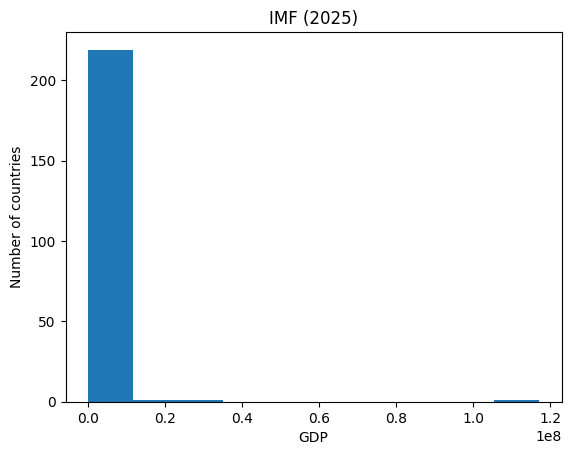

In [ ]:
import matplotlib.pyplot as plt

# Build a histogram of IMF_Forecast
plt.hist(df['IMF (2025)'], bins=10)
plt.title('IMF (2025)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()


На гістограмі можно чітко побачити, що більшість країн перебувають у нижній частині між 0 та 0.25 х 10 у 7. Є деякі країни з більшим ВВП в районі 0.5 х 10 у 7-ій, але є одиничні випадкі далі у верхній межі.

14.Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF 2025, WorldBank 2022-2024, United Nations 2023). Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
# Calculate share of world GDP for each country for each year
df['IMF_Share'] = df['IMF (2025)'] / df['IMF (2025)'].sum()
df['WB_Share'] = df['World Bank (2022–24)'] / df['World Bank (2022–24)'].sum()
df['UN_Share'] = df['United Nations (2023)'] / df['United Nations (2023)'].sum()

df.head(10)

,Country,IMF (2025),World Bank (2022–24),United Nations (2023),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
0,World,117165394.0,111326370.0,100834796.0,5839024.0,5.240562e+07,0.500714,0.500570,0.487254
1,United States,30615743.0,29184890.0,27720700.0,1430853.0,1.392172e+07,0.130838,0.131227,0.133952
2,China[n 1],19398577.0,18743803.0,17794782.0,654774.0,9.019537e+06,0.082901,0.084280,0.085988
3,Germany,5013574.0,4659929.0,4525704.0,353645.0,2.199360e+06,0.021426,0.020953,0.021869
4,Japan,4279828.0,4026211.0,4204495.0,253617.0,1.961166e+06,0.018290,0.018104,0.020317
5,India,4125213.0,3912686.0,3575778.0,212527.0,1.843283e+06,0.017629,0.017593,0.017279
6,United Kingdom,3958780.0,3643834.0,3380855.0,314946.0,1.689703e+06,0.016918,0.016384,0.016337
7,France,3361557.0,3162079.0,3051832.0,199478.0,1.501653e+06,0.014366,0.014218,0.014747
8,Italy,2543677.0,2372775.0,2300941.0,170902.0,1.122076e+06,0.010871,0.010669,0.011119
9,Russia,2540656.0,2173836.0,2008419.0,366820.0,9.631075e+05,0.010858,0.009774,0.009705


15.Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [ ]:
# Find top 10 countries with the most significant change in share of world GDP between IMF and UN
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN_Share'])
df_top10 = df.nlargest(10, 'IMF_UN_Diff')
df_top10

,Country,IMF (2025),World Bank (2022–24),United Nations (2023),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share,IMF_UN_Diff
0,World,117165394.0,111326370.0,100834796.0,5839024.0,5.240562e+07,0.500714,0.500570,0.487254,0.013459
1,United States,30615743.0,29184890.0,27720700.0,1430853.0,1.392172e+07,0.130838,0.131227,0.133952,0.003114
2,China[n 1],19398577.0,18743803.0,17794782.0,654774.0,9.019537e+06,0.082901,0.084280,0.085988,0.003087
4,Japan,4279828.0,4026211.0,4204495.0,253617.0,1.961166e+06,0.018290,0.018104,0.020317,0.002027
16,Turkey,1565471.0,1323255.0,1118253.0,242216.0,5.764683e+05,0.006690,0.005950,0.005404,0.001287
9,Russia,2540656.0,2173836.0,2008419.0,366820.0,9.631075e+05,0.010858,0.009774,0.009705,0.001153
59,Nigeria,188271.0,187760.0,374984.0,511.0,1.528782e+05,0.000805,0.000844,0.001812,0.001007
14,South Korea,1858572.0,1712793.0,1839058.0,145779.0,8.313624e+05,0.007943,0.007701,0.008887,0.000944
11,Brazil,2256910.0,2179412.0,2191132.0,77498.0,1.066372e+06,0.009645,0.009800,0.010588,0.000943
15,Australia,1829508.0,1752193.0,1775628.0,77315.0,8.548437e+05,0.007819,0.007879,0.008580,0.000762


Заголом можно побачити, що частка ВВП в світовій економіці залишається досить стабільною, що навіть найбільша зміна все ще у межах десятинної частини відсотку

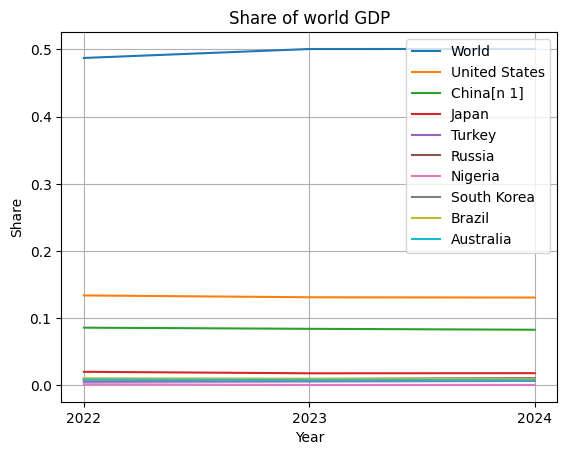

In [ ]:
for index, row in df_top10.iterrows():
    plt.plot(row[['UN_Share', 'WB_Share', 'IMF_Share']], label=row['Country'])

plt.title('Share of world GDP')
plt.xlabel('Year')
plt.xticks(ticks=[0, 1, 2], labels=['2022', '2023', '2024'])
plt.ylabel('Share')
plt.legend()
plt.grid()
plt.show()